# Learning to Implement Variational Autoencoders

## TO-DO:
- implement VQ-VAE

# References
- DiVAE: https://arxiv.org/abs/2512.03928 + https://github.com/alessimichele/DiVAE-EurIPS/tree/main

In [1]:
from collections.abc import Callable
from copy import deepcopy
from dadapy import Data
from IPython.display import HTML
import gc
import matplotlib
import matplotlib.animation as animation
import math
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.distributions as td
from torch.distributions.mixture_same_family import MixtureSameFamily
from torch.distributions.kl import register_kl
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.utils.parametrize as parametrize
from torchmetrics.image.fid import FrechetInceptionDistance
from torchvision import datasets, transforms
from torchvision.utils import save_image, make_grid
from torchvision.transforms.functional import to_pil_image
from tqdm import tqdm
from typing import List, Tuple, Dict, Iterable
from wand.image import Image as WImage

import sys
sys.path.append("/home/alzub/projects/ggdl_self_learn/code/")
from plot_utils import set_plot_style
from nn_.mlp import MLP
from generative.conditioning import FiLMedCNN2DToFC, FiLMedTCNN2DFromFC
from generative.base_dists import GaussianBase, MixtureOfGaussiansBase, VampBase
from generative.vae import (
    GaussianEncoder, GaussianDecoder, VAE, ELBO, ELBOAnnealedBeta)
from generative.utils import create_linear_schedule
from utilities.prebuilt_nns import create_mnist_classifier
from utilities.metrics import FIDEvaluator

In [2]:
set_plot_style()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PROJECT_DIR = Path("/home/alzub/projects/ggdl_self_learn")
DATA_DIR = PROJECT_DIR / "data"
MODEL_DIR = DATA_DIR / "models/vae"
SAMPLE_DIR = DATA_DIR / "samples/vae"

PRIOR_NAME_MAP = {
    "std": "Standard Gaussian", "mog": "Mixture of Gaussians",
    "vamp": "VampPrior"
}

plt.rcParams["animation.html"] = "jshtml"
matplotlib.rcParams['animation.embed_limit'] = 2**128
plt.ioff()

# 0. Prerequisites

## 0.1 Data

### 0.1.1 Toy Distributions

In [3]:
class TwoGaussians:
    def __init__(self):
        """
        A simple class to define an uneven mixture of two Gaussians.
        """

        mixture = td.Categorical(torch.tensor([1/5, 4/5]))
        components = td.Independent(td.Normal(
            torch.Tensor([
                [0.75, 0.75],
                [0.25, 0.25]
            ]),
            torch.Tensor([
                [0.1, 0.1],
                [0.1, 0.1]
            ])
        ), 1)
        self.distribution = MixtureSameFamily(mixture, components)

        self.xlim = (0, 1)
        self.ylim = (0, 1)

    def __call__(self):
        """
        Return the distribution.
        Returns:
        distribution: [torch.distributions.Distribution]
        """
        return self.distribution


class ExtendedUniform(td.Uniform):
    def __init__(self, low, high, validate_args=None, outside_value=-float('inf')):
        """
        A uniform distribution that returns a constant value for values outside the support
        """
        super(ExtendedUniform, self).__init__(low, high, validate_args)
        self.outside_value = outside_value

    def log_prob(self, value):
        # Check if the value is within the support
        in_support = (value >= self.low) & (value <= self.high)
        safe_value = torch.where(in_support, value, self.low)
        log_prob = super().log_prob(safe_value)
        
        # Set log_prob to self.outside_value for values outside the support
        log_prob = torch.where(in_support, log_prob, torch.full_like(log_prob, self.outside_value))
        return log_prob
    
    @td.constraints.dependent_property(is_discrete=False, event_dim=0)
    def support(self):
        return td.constraints.real

class Chequerboard:
    def __init__(self, grid_size=3, bounds=[0.0, 1.0]):
        """
        A simple class to define the Chequerboard distribution.
        """

        square_size = (bounds[1] - bounds[0]) / grid_size

        weights = []
        low_list = []
        high_list = []
        for i in range(grid_size):
            for j in range(grid_size):
                if (i + j) % 2 == 0:
                    low_x = bounds[0] + i * square_size
                    high_x = low_x + square_size
                    low_y = bounds[0] + j * square_size
                    high_y = low_y + square_size
                    
                    low_list.append([low_x, low_y])
                    high_list.append([high_x, high_y])
                    weights.append(1.0)

        mixture = td.Categorical(torch.tensor(weights))
        #components = td.Independent(td.uniform.Uniform(torch.tensor(low_list), torch.tensor(high_list)), 1)
        components = td.Independent(ExtendedUniform(torch.tensor(low_list), torch.tensor(high_list)), 1)
        self.distribution = MixtureSameFamily(mixture, components)

        self.xlim = bounds
        self.ylim = bounds

    def __call__(self):
        """
        Return the distribution.
        Returns:
        distribution: [torch.distributions.Distribution]
        """
        return self.distribution

### 0.1.2 MNIST

In [4]:
batch_size = 256

mnist_train_loader = torch.utils.data.DataLoader(
    datasets.MNIST(
        PROJECT_DIR / "data", train=True, download=True,
        transform=transforms.Compose([transforms.ToTensor()])
    ),
    batch_size=batch_size, shuffle=True
)
mnist_test_loader = torch.utils.data.DataLoader(
    datasets.MNIST(
        PROJECT_DIR / "data", train=False, download=True,
        transform=transforms.Compose([transforms.ToTensor()])
    ),
    batch_size=batch_size*4, shuffle=True
)

# 1. VAE Architectures

## 1.1 For ToyData

In [5]:
def make_toy1_encoder(x_sample_size: int, latent_size: int) -> nn.Module:
    return GaussianEncoder(MLP(
        x_sample_size, latent_size*2, [32, 128, 32],
        act_funs=[nn.GELU]*3 + [None]
    ))

def make_toy1_decoder(
    x_sample_size: int, latent_size: int, var_type: str="diagonal"
) -> nn.Module:
    return GaussianDecoder(
        MLP(
            latent_size, x_sample_size, [32, 128, 32],
            act_funs=[nn.GELU]*3 + [None]
        ), (x_sample_size,), variance_type=var_type
    )

def make_toy2_encoder(x_sample_size: int, latent_size: int) -> nn.Module:
    return GaussianEncoder(MLP(
        x_sample_size, latent_size*2, [256, 128, 64, 32],
        act_funs=[nn.GELU]*4 + [None]
    ))

def make_toy2_decoder(
    x_sample_size: int, latent_size: int, var_type: str="diagonal"
) -> nn.Module:
    return GaussianDecoder(
        MLP(
            latent_size, x_sample_size, [32, 64, 128, 256],
            act_funs=[nn.GELU]*4 + [None]
        ), (x_sample_size,), variance_type=var_type
    )

## 1.2 For MNIST

In [6]:
def make_mnist_enc_net(
    n_feats: int, n_channels: int, embedding_size: int, latent_size,
    n_classes: int=10, conv_act_fun=nn.LogSigmoid, film_act_fun=nn.GELU,
    use_batchnorm: bool=True
) -> nn.Module:
    enc_net = FiLMedCNN2DToFC(
        embedding_size, n_classes,
        n_feats, n_channels, 256, [32, 64, 128, 256],
        # convolution
        [3, 3, 3, 3, 3], [2, 2, 2, 2, 2], [1, 1, 1, 1, 1],
        # pooling := None
        [0, 0, 0, 0, 0], [2, 2, 2, 2, 1], [0, 0, 1, 0, 0],
        None, latent_size * 2, use_batchnorm=use_batchnorm,
        conv_act_fun=conv_act_fun, film_act_fun=film_act_fun
    )
    return enc_net

def make_mnist_dec_net(
    embedding_size: int, latent_size, n_classes: int=10,
    tconv_act_fun=nn.LogSigmoid, film_act_fun=nn.GELU,
    use_batchnorm: bool=True
) -> nn.Module:
    dec_net = FiLMedTCNN2DFromFC(
        embedding_size, n_classes,
        4, 256, 1, [256, 128, 64, 32],
        [3, 3, 3, 3, 3], [2, 2, 2, 1, 1], [1, 1, 1, 2, 2], [1, 1, 1, 0, 0],
        latent_size, 4096, use_batchnorm=use_batchnorm,
        tconv_act_fun=tconv_act_fun, fc_act_fun=film_act_fun,
        no_last_act_fun=True, film_act_fun=film_act_fun
    )
    return dec_net

## 1.3 Helper Functions

In [7]:
def evaluate_elbo(
    model: nn.Module, data_loader: torch.utils.data.DataLoader,
    reduction: str|None=None
) -> Tuple[torch.Tensor, torch.Tensor]|torch.Tensor:
    loss_fun = ELBO()
    model.eval()
    elbo = []

    with torch.no_grad():
        for x, y in data_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            post, lik = model(x, y)
            loss, _ = loss_fun(model.prior(), post, lik, x)
            elbo.append(loss)
    
    elbo = torch.stack(elbo)
    if not reduction:
        return elbo
    else:
        if reduction == "mean":
            return  torch.std_mean(elbo)
        elif reduction == "sum":
            return torch.sum(elbo)
        
def evaluate_aggregate_posterior(
    model: nn.Module, data_loader: torch.utils.data.DataLoader
) -> pd.DataFrame:
    all_samples = []
    all_labels = []
    model.eval()
    with torch.no_grad():
        for x_test, y_test in data_loader:
            x_test, y_test = x_test.to(DEVICE), y_test.to(DEVICE)
            post, _ = model(x_test, y_test)

            post_sampled = post.rsample().detach().cpu()
            all_samples.append(post_sampled)
            all_labels.append(y_test)

    all_samples = torch.cat(all_samples)
    all_labels = torch.cat(all_labels)

    all_samples = all_samples.numpy()
    post_df = pd.DataFrame({
        "x": all_samples[:, 0], "y": all_samples[:, 1],
        "class": all_labels.cpu().numpy()
    })
    post_df["class"] = post_df["class"].astype("category")
    return post_df

def evaluate_prior_pdf(
    min_: Tuple[float, float], max_: Tuple[float, float], prior_: nn.Module,
    steps: int=200
) -> Tuple[np.array, np.array, np.array]:
    grid_x = np.linspace(min_[0], max_[0], steps)
    grid_y = np.linspace(min_[1], max_[1], steps)
    X, Y = np.meshgrid(grid_x, grid_y)
    points = np.stack([X, Y], axis=-1)
    points_torch = torch.from_numpy(points.astype(np.float32))
    flattened_points = points_torch.reshape(-1, 2).to(DEVICE)
    log_probs = prior_.log_prob(flattened_points).detach()
    pdf = log_probs.reshape(steps, steps).cpu().numpy()
    return X, Y, pdf

In [8]:
def prior_log_prob_for_alignment(
    model: nn.Module, z: torch.Tensor) -> torch.Tensor:
    if not isinstance(model.prior, VampBase):
        return model.prior().log_prob(z)

    enc_params = list(model.prior.enc.parameters())
    flags = [p.requires_grad for p in enc_params]

    for p in enc_params:
        p.requires_grad_(False)

    try:
        logp = model.prior().log_prob(z)
    finally:
        for p, flag in zip(enc_params, flags):
            p.requires_grad_(flag)

    return logp

# 2. VAEs on Toy Data

## 2.1 TwoGaussians

In [9]:
# Generate the data
n_data = 10000000
toy = TwoGaussians()
train_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)

### 2.1.1 Continuous-Latent VAEs on TwoGaussians

In [39]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)
epochs = 3

latent_size = 2
for i, prior_type in enumerate(["std", "mog", "vamp"]):
    enc = make_toy1_encoder(x_sample_size, latent_size)
    dec = make_toy1_decoder(x_sample_size, latent_size)
    match prior_type:
        case "std":
            prior = GaussianBase((latent_size,))
        case "mog":
            prior = MixtureOfGaussiansBase((latent_size,), 2)
        case "vamp":
            prior = VampBase((x_sample_size,), 4, enc)
    model = VAE(prior, enc, dec).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()

    total_steps = len(train_loader)*epochs
    loss_fun = ELBOAnnealedBeta(total_steps, 0.0, device=DEVICE).to(DEVICE)
    progress_bar = tqdm(range(total_steps), desc="Training")
    s = 0
    for epoch in range(epochs):
        for x in train_loader:
            optimizer.zero_grad()

            x = x.to(DEVICE)

            post, lik = model(x)
            loss, (recon, regul) = loss_fun(model.prior(), post, lik, x, s)

            loss.backward()
            optimizer.step()

            # Update progress bar
            progress_bar.set_postfix(
                epoch=f"{epoch+1}/{epochs}", neg_elbo=f"⠀{loss.item():12.4f}",
                recon=f"⠀{recon.mean().item():12.4f}",
                regul=f"⠀{regul.mean().item():12.4f}"
            )
            progress_bar.update()

            s += 1

    torch.save(
        model.state_dict(),
        MODEL_DIR / f"toy1_vae_{prior_type}_{epochs}_n_epochs.pt"
    )

Training: 100%|██████████| 3000/3000 [12:23<00:00,  3.09it/s, epoch=3/3, neg_elbo=⠀     -1.2714, recon=⠀      1.8297, regul=⠀      0.5584]

In [40]:
progress_bar.reset()

Training:   0%|          | 0/3000 [00:00<?, ?it/s, epoch=3/3, neg_elbo=⠀     -1.2714, recon=⠀      1.8297, regul=⠀      0.5584]           

/home/alzub/tmp/ipykernel_2131585/1496097975.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


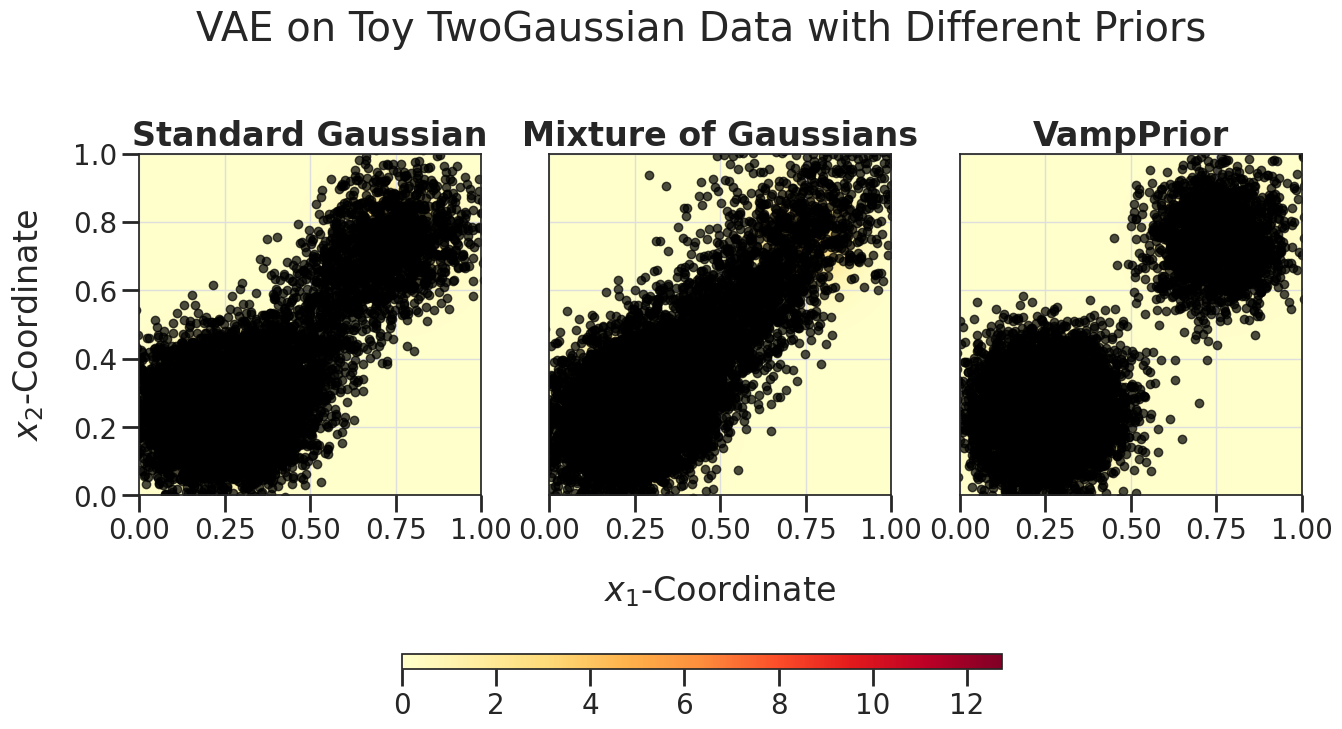

In [ ]:
coordinates = [
    [[x,y] for x in np.linspace(*toy.xlim, 1000)]
    for y in np.linspace(*toy.ylim, 1000)
]
prob = torch.exp(toy().log_prob(torch.tensor(coordinates)))

fig = plt.figure(figsize=(15, 15))
gs_plot = fig.add_gridspec(1, 3, bottom=0.1)
gs_cbar = fig.add_gridspec(1, 1, top=0.27, bottom=0.26, left=0.3, right=0.7)

epochs = 3
latent_size = 2
enc = make_toy1_encoder(x_sample_size, latent_size)
dec = make_toy1_decoder(x_sample_size, latent_size)
for i, prior_type in enumerate(["std", "mog", "vamp"]):
    match prior_type:
        case "std":
            prior = GaussianBase((latent_size,))
        case "mog":
            prior = MixtureOfGaussiansBase((latent_size,), 2)
        case "vamp":
            prior = VampBase((x_sample_size,), 4, enc)
    model = VAE(prior, enc, dec).to(DEVICE)
    model.load_state_dict(torch.load(
        MODEL_DIR / f"toy1_vae_{prior_type}_{epochs}_n_epochs.pt",
        map_location=torch.device(DEVICE)
    ))
    with torch.no_grad():
        model.eval()
        samples = model.sample((10000,))
        samples = samples.detach().cpu().numpy()

    ax = fig.add_subplot(gs_plot[i])
    im = ax.imshow(
        prob, extent=[toy.xlim[0], toy.xlim[1], toy.ylim[0], toy.ylim[1]],
        origin='lower', cmap='YlOrRd'
    )

    ax.scatter(samples[:, 0], samples[:, 1], alpha=0.7, color="black")

    ax.set_xlim(toy.xlim)
    ax.set_ylim(toy.ylim)
    ax.set_aspect("equal")
        
    if i > 0:
        ax.tick_params(left=False, labelleft=False)
        ax.set_ylabel("")
    else:
        ax.set_ylabel("$x_2$-Coordinate", labelpad=20)
    
    if i != 1:
        ax.set_xlabel("")
    else:
        ax.set_xlabel("$x_1$-Coordinate", labelpad=20)
    
    ax.set_title(PRIOR_NAME_MAP[prior_type], weight="bold")
    
ax_cbar = fig.add_subplot(gs_cbar[0])
fig.colorbar(im, location="bottom", cax=ax_cbar)

fig.suptitle("VAE on Toy TwoGaussian Data with Different Priors", y=0.7)

plt.show()

**Density Informed (Using Direct Aligner)**

In [14]:
X = toy().sample((n_data,)).numpy()
toy_data = Data(X)
toy_data.compute_distances(maxk=30)
toy_data.distances = toy_data.remove_zero_dists(toy_data.distances)
id, id_error, id_dists = toy_data.compute_id_2NN()
log_den, log_den_error = toy_data.compute_density_PAk()

/home/alzub/miniconda3/envs/ggdl/lib/python3.12/site-packages/dadapy/_utils/utils.py:152: UserWarning: There are points with neighbours at 0 distance, meaning the dataset probably has identical points.
This can cause problems in various routines.
We suggest to either perform smearing of distances using
remove_zero_dists()
or remove identical points using
remove_identical_points()).
  warnings.warn(
/home/alzub/miniconda3/envs/ggdl/lib/python3.12/site-packages/dadapy/_utils/density_estimation.py:187: UserWarning: Found 135 nearest neighbours at identical distance, adding a small amount of noise
  warnings.warn(


In [15]:
# dataloader(s) augmented with (non-parametric) density estimate
denaug_train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(
        torch.from_numpy(X).to(torch.float),
        torch.from_numpy(log_den).to(torch.float),
        torch.from_numpy(log_den_error).to(torch.float)
    ),
    batch_size=10000, shuffle=True
)

In [17]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)
epochs = 3

loader_len = len(denaug_train_loader)
latent_size = 2
for i, prior_type in enumerate(["std", "mog", "vamp"]):
    enc = make_toy1_encoder(x_sample_size, latent_size)
    dec = make_toy1_decoder(x_sample_size, latent_size)
    match prior_type:
        case "std":
            prior = GaussianBase((latent_size,))
        case "mog":
            prior = MixtureOfGaussiansBase((latent_size,), 2)
        case "vamp":
            prior = VampBase((x_sample_size,), 4, enc)
    model = VAE(prior, enc, dec).to(DEVICE)
    learnable_offset = nn.Parameter(
        torch.ones((1,), dtype=torch.float32, device=DEVICE)*0.5,
        requires_grad=True
    )

    optimizer = torch.optim.Adam(
        list(model.parameters()) + [learnable_offset], lr=1e-3)
    model.train()

    total_steps = loader_len*epochs
    loss_fun = ELBOAnnealedBeta(total_steps, 0.0, device=DEVICE).to(DEVICE)
    gammas = create_linear_schedule(
        total_steps, 0, 1.0, burnin_frac=0.3, ramp_frac=0.3, device=DEVICE)
    progress_bar = tqdm(range(total_steps), desc="Training")
    s = 0
    for epoch in range(epochs):
        for x, log_est, est_err in denaug_train_loader:
            optimizer.zero_grad()

            x = x.to(DEVICE)
            log_est, est_err = log_est.to(DEVICE), est_err.to(DEVICE)

            post, lik = model(x)
            neg_elbo, (recon, regul) = loss_fun(model.prior(), post, lik, x, s)

            # direct aligner to non-parametric density estimate
            latent_sample = post.mean
            prior_log_prob = prior_log_prob_for_alignment(model, latent_sample)

            #log_est = log_est + learnable_offset

            align_weight = est_err.clamp_min(1e-3).pow(-1).clamp_max(9.99999e5)
            if torch.all(align_weight == 9.99999e5):
                align_weight = torch.ones_like(align_weight)
            align_loss = torch.sqrt((
                align_weight
                    * F.huber_loss(prior_log_prob, log_est, reduction="none")
            ).mean())

            loss = neg_elbo + gammas[s] * align_loss
            loss.backward()
            optimizer.step()

            # Update progress bar
            progress_bar.set_postfix(
                epoch=f"{epoch+1}/{epochs}", neg_elbo=f"⠀{loss.item():12.4f}",
                recon=f"⠀{recon.mean().item():12.4f}",
                regul=f"⠀{regul.mean().item():12.4f}",
                alignment=f"⠀{(gammas[s] * align_loss).item():12.4f}"
            )
            progress_bar.update()

            s += 1

    torch.save(
        model.state_dict(),
        MODEL_DIR / f"toy1_divae_{prior_type}_{epochs}_n_epochs.pt"
    )

Training: 100%|██████████| 3000/3000 [16:38<00:00,  3.00it/s, alignment=⠀      0.6722, epoch=3/3, neg_elbo=⠀     -0.3013, recon=⠀      2.4735, regul=⠀      1.5000]


In [18]:
progress_bar.reset()

/home/alzub/tmp/ipykernel_11454/654190522.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


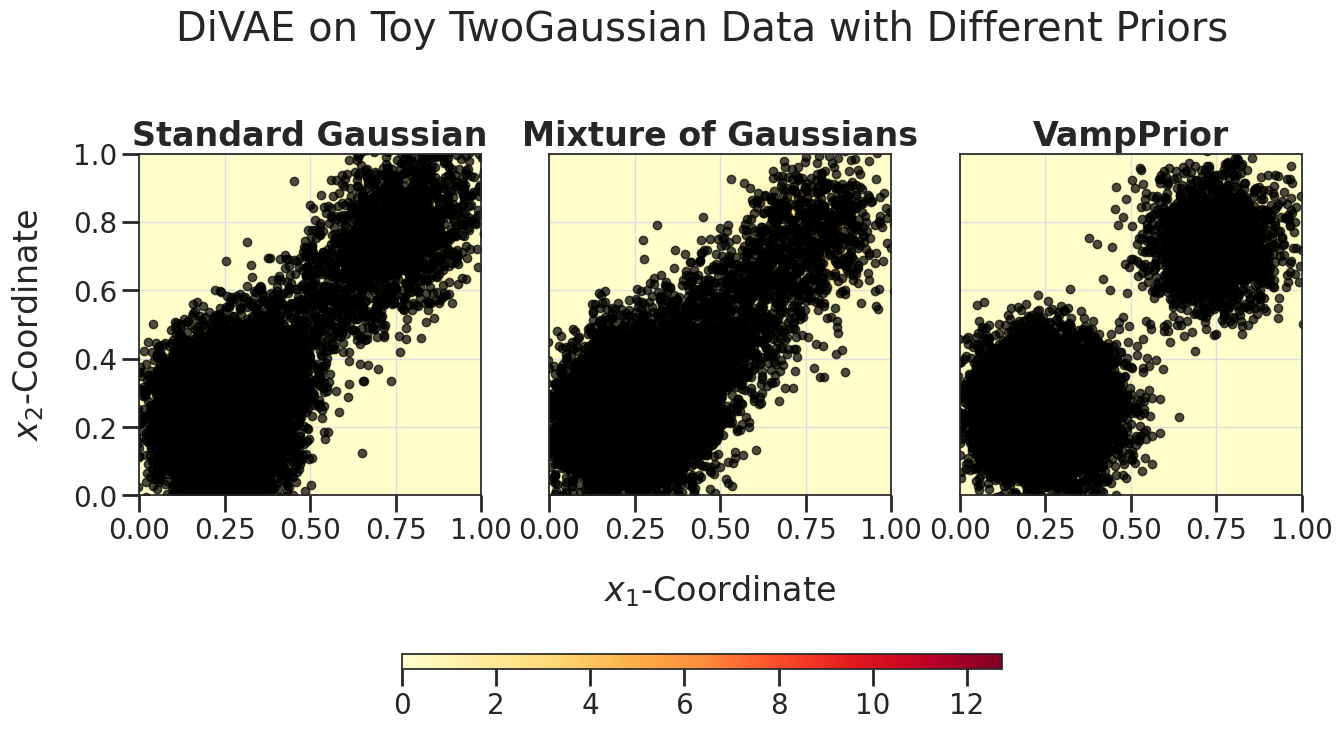

In [19]:
coordinates = [
    [[x,y] for x in np.linspace(*toy.xlim, 1000)]
    for y in np.linspace(*toy.ylim, 1000)
]
prob = torch.exp(toy().log_prob(torch.tensor(coordinates)))

fig = plt.figure(figsize=(15, 15))
gs_plot = fig.add_gridspec(1, 3, bottom=0.1)
gs_cbar = fig.add_gridspec(1, 1, top=0.27, bottom=0.26, left=0.3, right=0.7)

epochs = 3
latent_size = 2
enc = make_toy1_encoder(x_sample_size, latent_size)
dec = make_toy1_decoder(x_sample_size, latent_size)
for i, prior_type in enumerate(["std", "mog", "vamp"]):
    match prior_type:
        case "std":
            prior = GaussianBase((latent_size,))
        case "mog":
            prior = MixtureOfGaussiansBase((latent_size,), 2)
        case "vamp":
            prior = VampBase((x_sample_size,), 4, enc)
    model = VAE(prior, enc, dec).to(DEVICE)
    model.load_state_dict(torch.load(
        MODEL_DIR / f"toy1_divae_{prior_type}_{epochs}_n_epochs.pt",
        map_location=torch.device(DEVICE)
    ))
    with torch.no_grad():
        model.eval()
        samples = model.sample((10000,))
        samples = samples.detach().cpu().numpy()

    ax = fig.add_subplot(gs_plot[i])
    im = ax.imshow(
        prob, extent=[toy.xlim[0], toy.xlim[1], toy.ylim[0], toy.ylim[1]],
        origin='lower', cmap='YlOrRd'
    )

    ax.scatter(samples[:, 0], samples[:, 1], alpha=0.7, color="black")

    ax.set_xlim(toy.xlim)
    ax.set_ylim(toy.ylim)
    ax.set_aspect("equal")
        
    if i > 0:
        ax.tick_params(left=False, labelleft=False)
        ax.set_ylabel("")
    else:
        ax.set_ylabel("$x_2$-Coordinate", labelpad=20)
    
    if i != 1:
        ax.set_xlabel("")
    else:
        ax.set_xlabel("$x_1$-Coordinate", labelpad=20)
    
    ax.set_title(PRIOR_NAME_MAP[prior_type], weight="bold")
    
ax_cbar = fig.add_subplot(gs_cbar[0])
fig.colorbar(im, location="bottom", cax=ax_cbar)

fig.suptitle("DiVAE on Toy TwoGaussian Data with Different Priors", y=0.7)

plt.show()

## 2.2 Chequerboard

In [9]:
# Generate the data
n_data = 10000000
toy = Chequerboard(bounds=[-2, 2])
train_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)

### 2.2.1 Continuous-Latent VAEs on Chequerboard

In [ ]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)
epochs = 3

latent_size = 2
for i, prior_type in enumerate(["std", "mog", "vamp"]):
    enc = make_toy2_encoder(x_sample_size, latent_size)
    dec = make_toy2_decoder(x_sample_size, latent_size)
    match prior_type:
        case "std":
            prior = GaussianBase((latent_size,))
        case "mog":
            prior = MixtureOfGaussiansBase((latent_size,), 5)
        case "vamp":
            prior = VampBase((x_sample_size,), 10, enc)
    model = VAE(prior, enc, dec).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    model.train()

    total_steps = len(train_loader)*epochs
    loss_fun = ELBOAnnealedBeta(total_steps, 0.0, device=DEVICE).to(DEVICE)
    progress_bar = tqdm(range(total_steps), desc="Training")
    s = 0
    for epoch in range(epochs):
        for x in train_loader:
            optimizer.zero_grad()

            x = x.to(DEVICE)

            post, lik = model(x)
            loss, (recon, regul) = loss_fun(model.prior(), post, lik, x, s)

            loss.backward()
            optimizer.step()

            # Update progress bar
            progress_bar.set_postfix(
                epoch=f"{epoch+1}/{epochs}", neg_elbo=f"⠀{loss.item():12.4f}",
                recon=f"⠀{recon.mean().item():12.4f}",
                regul=f"⠀{regul.mean().item():12.4f}"
            )
            progress_bar.update()

            s += 1

    torch.save(
        model.state_dict(),
        MODEL_DIR / f"toy2_vae_{prior_type}_{epochs}_n_epochs.pt"
    )
    del model
    gc.collect()
    torch.cuda.empty_cache()

Training: 100%|██████████| 3000/3000 [26:28<00:00,  1.70it/s, epoch=3/3, neg_elbo=⠀      3.1210, recon=⠀      1.5153, regul=⠀      4.6364]

In [14]:
progress_bar.reset()

Training:   0%|          | 0/3000 [00:00<?, ?it/s, epoch=3/3, neg_elbo=⠀      3.1210, recon=⠀      1.5153, regul=⠀      4.6364]           

/home/alzub/tmp/ipykernel_3473643/1830021240.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


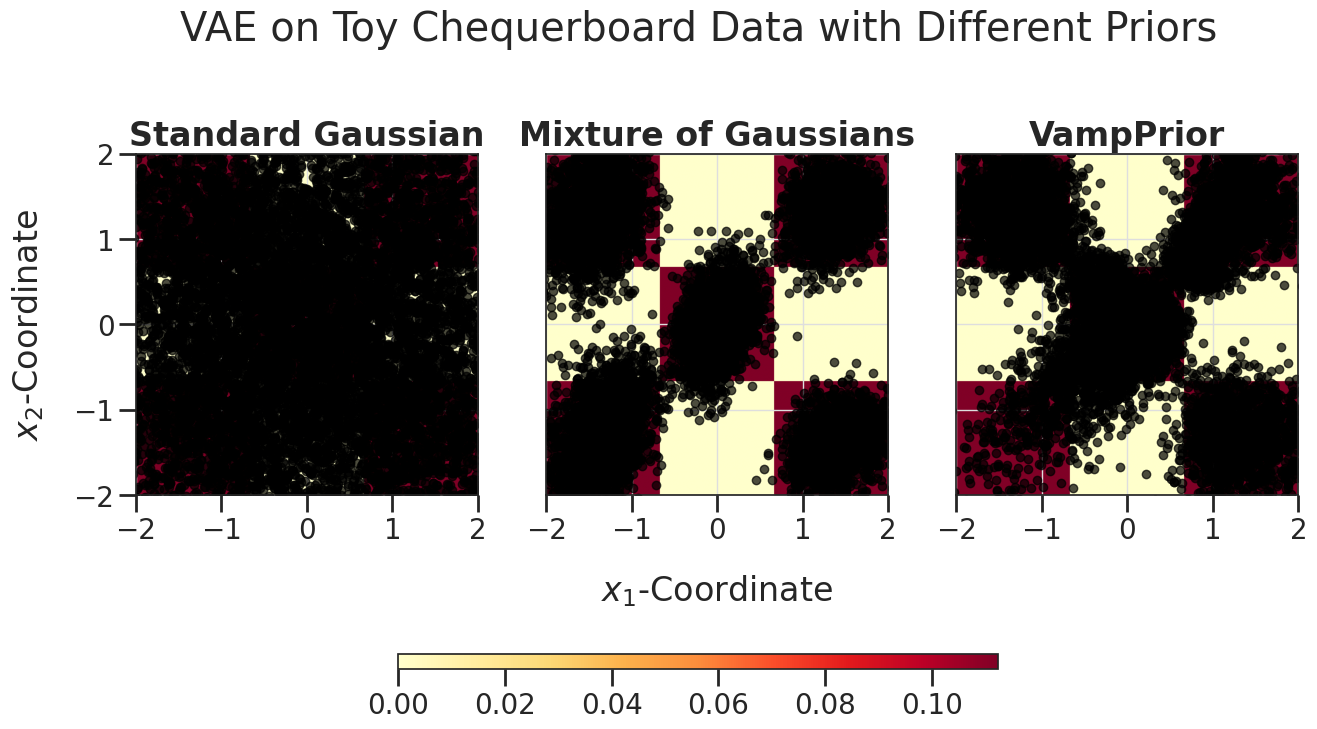

In [ ]:
coordinates = [
    [[x,y] for x in np.linspace(*toy.xlim, 1000)]
    for y in np.linspace(*toy.ylim, 1000)
]
prob = torch.exp(toy().log_prob(torch.tensor(coordinates)))

fig = plt.figure(figsize=(15, 15))
gs_plot = fig.add_gridspec(1, 3, bottom=0.1)
gs_cbar = fig.add_gridspec(1, 1, top=0.27, bottom=0.26, left=0.3, right=0.7)

epochs = 3
latent_size = 2
enc = make_toy2_encoder(x_sample_size, latent_size)
dec = make_toy2_decoder(x_sample_size, latent_size)
for i, prior_type in enumerate(["std", "mog", "vamp"]):
    match prior_type:
        case "std":
            prior = GaussianBase((latent_size,))
        case "mog":
            prior = MixtureOfGaussiansBase((latent_size,), 5)
        case "vamp":
            prior = VampBase((x_sample_size,), 10, enc)
    model = VAE(prior, enc, dec).to(DEVICE)
    model.load_state_dict(torch.load(
        MODEL_DIR / f"toy2_vae_{prior_type}_{epochs}_n_epochs.pt",
        map_location=torch.device(DEVICE)
    ))
    with torch.no_grad():
        model.eval()
        samples = model.sample((10000,))
        samples = samples.detach().cpu().numpy()

    ax = fig.add_subplot(gs_plot[i])
    im = ax.imshow(
        prob, extent=[toy.xlim[0], toy.xlim[1], toy.ylim[0], toy.ylim[1]],
        origin='lower', cmap='YlOrRd'
    )

    ax.scatter(samples[:, 0], samples[:, 1], alpha=0.7, color="black")

    ax.set_xlim(toy.xlim)
    ax.set_ylim(toy.ylim)
    ax.set_aspect("equal")
        
    if i > 0:
        ax.tick_params(left=False, labelleft=False)
        ax.set_ylabel("")
    else:
        ax.set_ylabel("$x_2$-Coordinate", labelpad=20)
    
    if i != 1:
        ax.set_xlabel("")
    else:
        ax.set_xlabel("$x_1$-Coordinate", labelpad=20)
    
    ax.set_title(PRIOR_NAME_MAP[prior_type], weight="bold")
    
ax_cbar = fig.add_subplot(gs_cbar[0])
fig.colorbar(im, location="bottom", cax=ax_cbar)

fig.suptitle("VAE on Toy Chequerboard Data with Different Priors", y=0.7)

plt.show()

**Density Informed (Using Direct Aligner)**

In [10]:
X = toy().sample((n_data,)).numpy()
toy_data = Data(X)
toy_data.compute_distances(maxk=30)
toy_data.distances = toy_data.remove_zero_dists(toy_data.distances)
id, id_error, id_dists = toy_data.compute_id_2NN()
log_den, log_den_error = toy_data.compute_density_PAk()

/home/alzub/miniconda3/envs/ggdl/lib/python3.12/site-packages/dadapy/_utils/density_estimation.py:187: UserWarning: Found 60 nearest neighbours at identical distance, adding a small amount of noise
  warnings.warn(


In [11]:
# dataloader(s) augmented with (non-parametric) density estimate
denaug_train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(
        torch.from_numpy(X).to(torch.float),
        torch.from_numpy(log_den).to(torch.float),
        torch.from_numpy(log_den_error).to(torch.float)
    ),
    batch_size=10000, shuffle=True
)

In [12]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)
epochs = 3

loader_len = len(denaug_train_loader)
latent_size = 2
for i, prior_type in enumerate(["std", "mog", "vamp"]):
    enc = make_toy2_encoder(x_sample_size, latent_size)
    dec = make_toy2_decoder(x_sample_size, latent_size)
    match prior_type:
        case "std":
            prior = GaussianBase((latent_size,))
        case "mog":
            prior = MixtureOfGaussiansBase((latent_size,), 5)
        case "vamp":
            prior = VampBase((x_sample_size,), 10, enc)
    model = VAE(prior, enc, dec).to(DEVICE)
    learnable_offset = nn.Parameter(
        torch.ones((1,), dtype=torch.float32, device=DEVICE)*0.5,
        requires_grad=True
    )

    optimizer = torch.optim.Adam(
        list(model.parameters()) + [learnable_offset], lr=1e-4)
    model.train()

    total_steps = loader_len*epochs
    loss_fun = ELBOAnnealedBeta(total_steps, 0.0, device=DEVICE).to(DEVICE)
    gammas = create_linear_schedule(
        total_steps, 0, 1.0, burnin_frac=0.3, ramp_frac=0.3, device=DEVICE)
    progress_bar = tqdm(range(total_steps), desc="Training")
    s = 0
    for epoch in range(epochs):
        for x, log_est, est_err in denaug_train_loader:
            optimizer.zero_grad()

            x = x.to(DEVICE)
            log_est, est_err = log_est.to(DEVICE), est_err.to(DEVICE)

            post, lik = model(x)
            neg_elbo, (recon, regul) = loss_fun(model.prior(), post, lik, x, s)

            # direct aligner to non-parametric density estimate
            latent_sample = post.mean
            prior_log_prob = prior_log_prob_for_alignment(model, latent_sample)

            #log_est = log_est + learnable_offset

            align_weight = est_err.clamp_min(1e-3).pow(-1).clamp_max(9.99999e5)
            if torch.all(align_weight == 9.99999e5):
                align_weight = torch.ones_like(align_weight)
            align_loss = torch.sqrt((
                align_weight
                    * F.huber_loss(prior_log_prob, log_est, reduction="none")
            ).mean())

            loss = neg_elbo + gammas[s] * align_loss
            loss.backward()
            optimizer.step()

            # Update progress bar
            progress_bar.set_postfix(
                epoch=f"{epoch+1}/{epochs}", neg_elbo=f"⠀{loss.item():12.4f}",
                recon=f"⠀{recon.mean().item():12.4f}",
                regul=f"⠀{regul.mean().item():12.4f}",
                alignment=f"⠀{(gammas[s] * align_loss).item():12.4f}"
            )
            progress_bar.update()

            s += 1

    torch.save(
        model.state_dict(),
        MODEL_DIR / f"toy2_divae_{prior_type}_{epochs}_n_epochs.pt"
    )
    del model
    gc.collect()
    torch.cuda.empty_cache() 


Training: 100%|██████████| 3000/3000 [28:56<00:00,  1.69it/s, alignment=⠀      1.1696, epoch=3/3, neg_elbo=⠀      4.7178, recon=⠀      1.2575, regul=⠀      4.8057]

In [13]:
progress_bar.reset()

Training:   0%|          | 0/3000 [00:00<?, ?it/s, alignment=⠀      1.1696, epoch=3/3, neg_elbo=⠀      4.7178, recon=⠀      1.2575, regul=⠀      4.8057]           

/home/alzub/tmp/ipykernel_3526888/3840685254.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


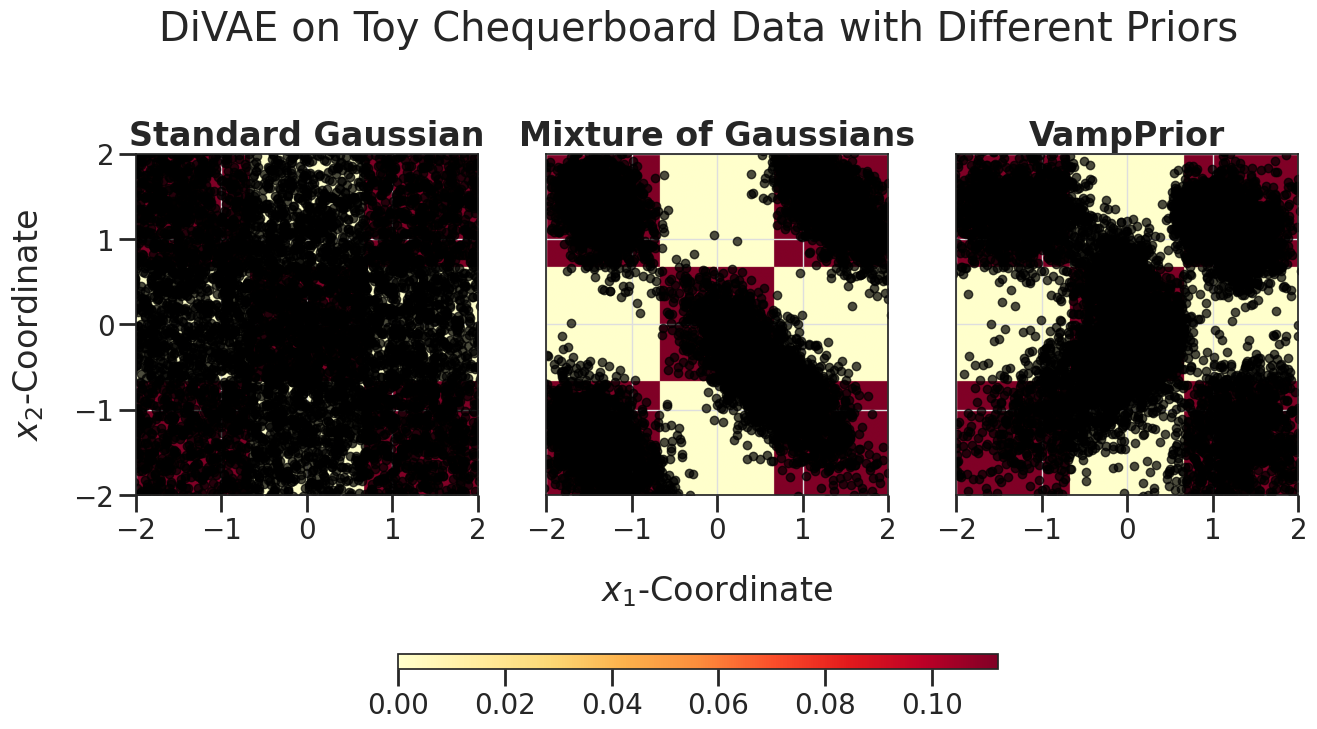

In [14]:
coordinates = [
    [[x,y] for x in np.linspace(*toy.xlim, 1000)]
    for y in np.linspace(*toy.ylim, 1000)
]
prob = torch.exp(toy().log_prob(torch.tensor(coordinates)))

fig = plt.figure(figsize=(15, 15))
gs_plot = fig.add_gridspec(1, 3, bottom=0.1)
gs_cbar = fig.add_gridspec(1, 1, top=0.27, bottom=0.26, left=0.3, right=0.7)

epochs = 3
latent_size = 2
enc = make_toy2_encoder(x_sample_size, latent_size)
dec = make_toy2_decoder(x_sample_size, latent_size)
for i, prior_type in enumerate(["std", "mog", "vamp"]):
    match prior_type:
        case "std":
            prior = GaussianBase((latent_size,))
        case "mog":
            prior = MixtureOfGaussiansBase((latent_size,), 5)
        case "vamp":
            prior = VampBase((x_sample_size,), 10, enc)
    model = VAE(prior, enc, dec).to(DEVICE)
    model.load_state_dict(torch.load(
        MODEL_DIR / f"toy2_divae_{prior_type}_{epochs}_n_epochs.pt",
        map_location=torch.device(DEVICE)
    ))
    with torch.no_grad():
        model.eval()
        samples = model.sample((10000,))
        samples = samples.detach().cpu().numpy()

    ax = fig.add_subplot(gs_plot[i])
    im = ax.imshow(
        prob, extent=[toy.xlim[0], toy.xlim[1], toy.ylim[0], toy.ylim[1]],
        origin='lower', cmap='YlOrRd'
    )

    ax.scatter(samples[:, 0], samples[:, 1], alpha=0.7, color="black")

    ax.set_xlim(toy.xlim)
    ax.set_ylim(toy.ylim)
    ax.set_aspect("equal")
        
    if i > 0:
        ax.tick_params(left=False, labelleft=False)
        ax.set_ylabel("")
    else:
        ax.set_ylabel("$x_2$-Coordinate", labelpad=20)
    
    if i != 1:
        ax.set_xlabel("")
    else:
        ax.set_xlabel("$x_1$-Coordinate", labelpad=20)
    
    ax.set_title(PRIOR_NAME_MAP[prior_type], weight="bold")
    
ax_cbar = fig.add_subplot(gs_cbar[0])
fig.colorbar(im, location="bottom", cax=ax_cbar)

fig.suptitle("DiVAE on Toy Chequerboard Data with Different Priors", y=0.7)

plt.show()

# 3. VAEs on Easy, Real Data

## 3.1 MNIST

### 3.1.1 Continuous-Latent VAEs on MNIST

In [ ]:
x_sample = next(iter(mnist_train_loader))[0][:1]
_, n_channels, height, width  = x_sample.size()
epochs = 100

latent_size = 2
embedding_size = 128
n_classes = 10

for i, prior_type in enumerate(["std", "mog", "vamp"]):
    if prior_type != "mog":
        continue
    enc = GaussianEncoder(make_mnist_enc_net(
        height, n_channels, embedding_size, latent_size, n_classes))
    dec = GaussianDecoder(
        make_mnist_dec_net(embedding_size, latent_size, n_classes),
        (n_channels, height, width), variance_type="scalar"
    )
    match prior_type:
        case "std":
            prior = GaussianBase((latent_size,))
        case "mog":
            prior = MixtureOfGaussiansBase(
                (latent_size,), 15, logvar_init=0.0, logvar_bounds=(-4.0, 3.0))
        case "vamp":
            prior = VampBase(
                (n_channels, height, width), 200, enc, n_classes=n_classes)
    model = VAE(prior, enc, dec).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()

    total_steps = len(mnist_train_loader)*epochs
    #loss_fun = ELBOAnnealedBeta(total_steps, 0.0, device=DEVICE).to(DEVICE)
    loss_fun = ELBO().to(DEVICE)
    progress_bar = tqdm(range(total_steps), desc="Training")
    s = 0

    for epoch in range(epochs):
        for x, y in mnist_train_loader:
            optimizer.zero_grad()

            x, y = x.to(DEVICE), y.to(DEVICE)

            post, lik = model(x, y=y)
            loss, (recon, regul) = loss_fun(model.prior(), post, lik, x, s)

            if prior_type == "mog":
                mix_probs = model.prior().mixture_distribution.probs
                mix_entropy = -(mix_probs * (mix_probs + 1e-8).log()).sum()
                loss = loss - 1e-3 * mix_entropy


            loss.backward()
            optimizer.step()

            # Update progress bar
            progress_bar.set_postfix(
                epoch=f"{epoch+1}/{epochs}", neg_elbo=f"⠀{loss.item():12.4f}",
                recon=f"⠀{recon.mean().item():12.4f}",
                regul=f"⠀{regul.mean().item():12.4f}"
            )
            progress_bar.update()

            s += 1

    torch.save(
        model.state_dict(),
        MODEL_DIR
            / f"mnist_vae_{prior_type}_{latent_size}_latentdim_{epochs}_n_epochs.pt"
    )

Training: 100%|██████████| 23500/23500 [21:28<00:00, 23.97it/s, epoch=100/100, neg_elbo=⠀   -313.3355, recon=⠀    323.4962, regul=⠀     10.1616]

Training: 100%|██████████| 23500/23500 [21:40<00:00, 23.97it/s, epoch=100/100, neg_elbo=⠀   -313.3355, recon=⠀    323.4962, regul=⠀     10.1616]

In [15]:
progress_bar.reset()

Training:   0%|          | 0/23500 [00:00<?, ?it/s]

In [36]:
x_sample = next(iter(mnist_train_loader))[0][:1]
_, n_channels, height, width  = x_sample.size()
epochs = 100

latent_size = 2
embedding_size = 128
n_classes = 10

for i, prior_type in enumerate(["std", "mog", "vamp"]):
    enc = GaussianEncoder(make_mnist_enc_net(
        height, n_channels, embedding_size, latent_size, n_classes))
    dec = GaussianDecoder(
        make_mnist_dec_net(embedding_size, latent_size, n_classes),
        (n_channels, height, width), variance_type="scalar"
    )
    match prior_type:
        case "std":
            prior = GaussianBase((latent_size,))
        case "mog":
            prior = MixtureOfGaussiansBase(
                (latent_size,), 15, logvar_bounds=(-4.0, 3.0))
        case "vamp":
            prior = VampBase(
                (n_channels, height, width), 200, enc, n_classes=n_classes)
    model = VAE(prior, enc, dec).to(DEVICE)

    model.load_state_dict(torch.load(
        MODEL_DIR
            / f"mnist_vae_{prior_type}_{latent_size}_latentdim_{epochs}_n_epochs.pt",
        map_location=torch.device(DEVICE)
    ))

    # Generate samples
    model.eval()
    with torch.no_grad():
        y = torch.arange(
            10, device=DEVICE, dtype=torch.long).expand((10, 10)).T.flatten()
        samples = model.sample((100,), y=y, use_mean=True).detach().cpu()
        save_image(
            samples,
            SAMPLE_DIR
                / f"mnist_vae_{prior_type}_{latent_size}_latentdim_{epochs}_n_epochs.png",
            normalize=False, nrow=10
        )

/home/alzub/tmp/ipykernel_111192/1087813204.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


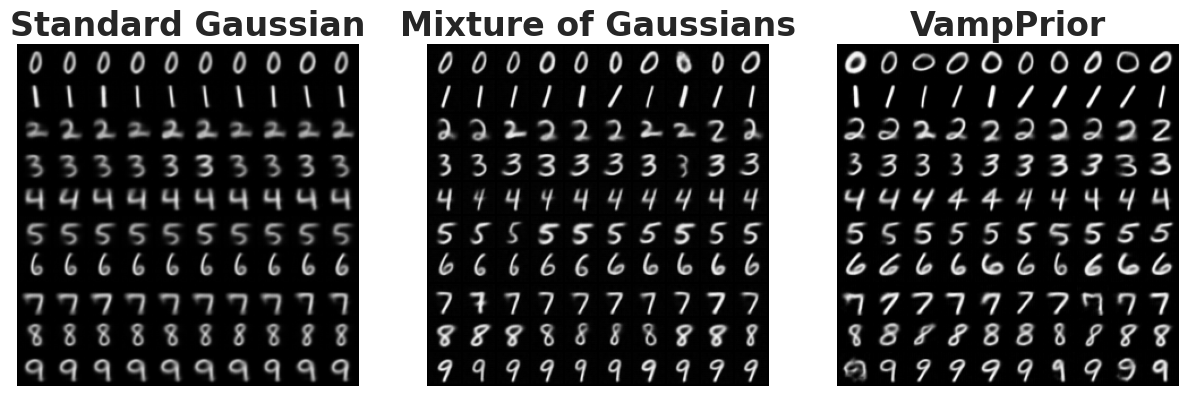

In [37]:
epochs = 100
latent_size = 2

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 10))

for i, prior_type in enumerate(["std", "mog", "vamp"]):
    img = WImage(
        filename=SAMPLE_DIR
            / f"mnist_vae_{prior_type}_{latent_size}_latentdim_{epochs}_n_epochs.png"
        )
    ax[i].imshow(img)
    ax[i].set_title(PRIOR_NAME_MAP[prior_type], weight="bold")
    ax[i].axis("off")

plt.show()

*Latent Space*

<>:71: SyntaxWarning: invalid escape sequence '\p'
<>:71: SyntaxWarning: invalid escape sequence '\p'
/home/alzub/tmp/ipykernel_111192/761478058.py:71: SyntaxWarning: invalid escape sequence '\p'
  0.1, -0.6, f"ELBO:\n{-elbo_mean:.3f} $\pm$ {elbo_var:.3f}",
/home/alzub/tmp/ipykernel_111192/761478058.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start sett

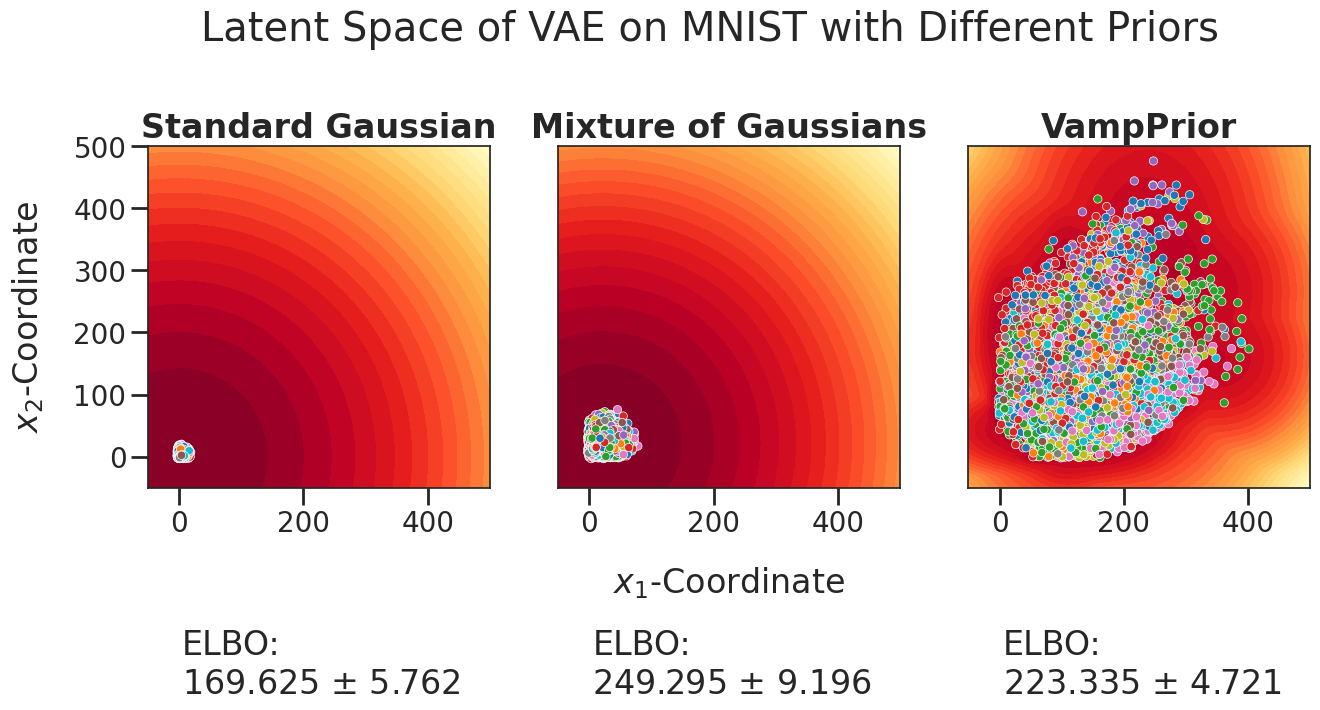

In [35]:
x_sample = next(iter(mnist_train_loader))[0][:1]
_, n_channels, height, width  = x_sample.size()
epochs = 100

latent_size = 2
embedding_size = 128
n_classes = 10

fig = plt.figure(figsize=(15, 15))
gs_plot = fig.add_gridspec(1, 3)#, bottom=0.1)
#gs_cbar = fig.add_gridspec(1, 1, top=0.27, bottom=0.26, left=0.3, right=0.7)

for i, prior_type in enumerate(["std", "mog", "vamp"]):
    enc = GaussianEncoder(make_mnist_enc_net(
        height, n_channels, embedding_size, latent_size, n_classes))
    dec = GaussianDecoder(
        make_mnist_dec_net(embedding_size, latent_size, n_classes),
        (n_channels, height, width), variance_type="scalar"
    )
    match prior_type:
        case "std":
            prior = GaussianBase((latent_size,))
        case "mog":
            prior = MixtureOfGaussiansBase(
                (latent_size,), 15, logvar_bounds=(-4.0, 3.0))
        case "vamp":
            prior = VampBase(
                (n_channels, height, width), 200, enc, n_classes=n_classes)
    model = VAE(prior, enc, dec).to(DEVICE)

    model.load_state_dict(torch.load(
        MODEL_DIR
            / f"mnist_vae_{prior_type}_{latent_size}_latentdim_{epochs}_n_epochs.pt",
        map_location=torch.device(DEVICE)
    ))

    post_df = evaluate_aggregate_posterior(model, mnist_test_loader)
    X, Y, pdf = evaluate_prior_pdf(
        (-50, -50),
        (500, 500),
        model.prior()
    )

    ax = fig.add_subplot(gs_plot[i])
    im = ax.contourf(
        X, Y, pdf, levels=30, cmap="YlOrRd",
        norm=Normalize(vmin=pdf.min(), vmax=pdf.max())
    )
    sns.scatterplot(
        data=post_df, x="x", y="y", hue="class", ax=ax, legend=False)

    ax.set_xlim(-50, 500)
    ax.set_ylim(-50, 500)
    ax.set_aspect("equal")
        
    if i > 0:
        ax.tick_params(left=False, labelleft=False)
        ax.set_ylabel("")
    else:
        ax.set_ylabel("$x_2$-Coordinate", labelpad=20)
    
    if i != 1:
        ax.set_xlabel("")
    else:
        ax.set_xlabel("$x_1$-Coordinate", labelpad=20)
    
    ax.set_title(PRIOR_NAME_MAP[prior_type], weight="bold")
    elbo_var, elbo_mean = evaluate_elbo(
        model, mnist_test_loader, reduction="mean")
    ax.text(
        0.1, -0.6, f"ELBO:\n{-elbo_mean:.3f} $\pm$ {elbo_var:.3f}",
        transform=ax.transAxes
    )

#ax_cbar = fig.add_subplot(gs_cbar[0])
#fig.colorbar(im, location="bottom", cax=ax_cbar)

fig.suptitle("Latent Space of VAE on MNIST with Different Priors", y=0.7)

plt.show()

**Density-Informed (Using Direct Aligner)**

In [9]:
latent_size = 2

X = mnist_train_loader.dataset.data.float().div(255.0)
y = mnist_train_loader.dataset.targets.long()
X_flat = X.view(X.size(0), -1).numpy()

pca = PCA(n_components=latent_size, random_state=0)
u = pca.fit_transform(X_flat)

jitter = 1e-6
rng = np.random.default_rng(0)
u = u + jitter * rng.standard_normal(u.shape)

mnist_pca_data = Data(u)
mnist_pca_data.compute_distances(maxk=200)
mnist_pca_data.distances = mnist_pca_data.remove_zero_dists(
    mnist_pca_data.distances)
id, id_error, id_dists = mnist_pca_data.compute_id_2NN()
log_den, log_den_error = mnist_pca_data.compute_density_PAk()

In [10]:
batch_size = 256
# dataloader(s) augmented with (non-parametric) density estimate
denaug_train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(
        X.unsqueeze(1),
        y,
        torch.from_numpy(log_den).to(torch.float),
        torch.from_numpy(log_den_error).to(torch.float)
    ),
    batch_size=batch_size, shuffle=True
)

In [ ]:
x_sample = next(iter(mnist_train_loader))[0][:1]
_, n_channels, height, width  = x_sample.size()
epochs = 100

latent_size = 2
embedding_size = 128
n_classes = 10

for i, prior_type in enumerate(["std", "mog", "vamp"]):
    enc = GaussianEncoder(make_mnist_enc_net(
        height, n_channels, embedding_size, latent_size, n_classes))
    dec = GaussianDecoder(
        make_mnist_dec_net(embedding_size, latent_size, n_classes),
        (n_channels, height, width), variance_type="scalar"
    )
    match prior_type:
        case "std":
            prior = GaussianBase((latent_size,))
        case "mog":
            prior = MixtureOfGaussiansBase(
                (latent_size,), 15, logvar_init=0.0, logvar_bounds=(-4.0, 3.0))
        case "vamp":
            prior = VampBase(
                (n_channels, height, width), 200, enc, n_classes=n_classes)
    model = VAE(prior, enc, dec).to(DEVICE)
    learnable_offset = nn.Parameter(
        torch.ones((1,), dtype=torch.float32, device=DEVICE)*0.5,
        requires_grad=True
    )

    optimizer = torch.optim.Adam(
        list(model.parameters()) + [learnable_offset], lr=1e-3)
    total_steps = len(mnist_train_loader)*epochs
    gammas = create_linear_schedule(
        total_steps, 0, 1.0, burnin_frac=0.3, ramp_frac=0.3, device=DEVICE)
    model.train()

    #loss_fun = ELBOAnnealedBeta(total_steps, 0.0, device=DEVICE).to(DEVICE)
    loss_fun = ELBO().to(DEVICE)
    progress_bar = tqdm(range(total_steps), desc="Training")
    s = 0

    for epoch in range(epochs):
        for x, y, log_est, est_err in denaug_train_loader:
            optimizer.zero_grad()

            x, y = x.to(DEVICE), y.to(DEVICE)
            log_est, est_err = log_est.to(DEVICE), est_err.to(DEVICE)

            post, lik = model(x, y=y)
            neg_elbo, (recon, regul) = loss_fun(model.prior(), post, lik, x, s)

            if prior_type == "mog":
                mix_probs = model.prior().mixture_distribution.probs
                mix_entropy = -(mix_probs * (mix_probs + 1e-8).log()).sum()
                neg_elbo = neg_elbo - 1e-3 * mix_entropy

            # direct aligner to non-parametric density estimate
            latent_sample = post.mean
            prior_log_prob = prior_log_prob_for_alignment(model, latent_sample)

            #log_est = log_est + learnable_offset

            align_weight = est_err.clamp_min(1e-3).pow(-1).clamp_max(9.99999e5)
            if torch.all(align_weight == 9.99999e5):
                align_weight = torch.ones_like(align_weight)
            align_loss = torch.sqrt((
                align_weight
                    * F.huber_loss(prior_log_prob, log_est, reduction="none")
            ).mean())

            loss = neg_elbo + gammas[s] * align_loss

            loss.backward()
            optimizer.step()

            # Update progress bar
            progress_bar.set_postfix(
                epoch=f"{epoch+1}/{epochs}", neg_elbo=f"⠀{loss.item():12.4f}",
                recon=f"⠀{recon.mean().item():12.4f}",
                regul=f"⠀{regul.mean().item():12.4f}",
                alignment=f"⠀{(gammas[s] * align_loss).item():12.4f}"
            )
            progress_bar.update()

            s += 1

    torch.save(
        model.state_dict(),
        MODEL_DIR
            / f"mnist_divae_{prior_type}_{latent_size}_latentdim_{epochs}_n_epochs.pt"
    )

Training: 100%|██████████| 23500/23500 [2:17:19<00:00,  2.68it/s, alignment=⠀      6.1869, epoch=100/100, neg_elbo=⠀   -293.8479, recon=⠀    307.4704, regul=⠀      7.4356] 

In [12]:
progress_bar.reset()

Training:   0%|          | 0/23500 [00:00<?, ?it/s, alignment=⠀      6.1869, epoch=100/100, neg_elbo=⠀   -293.8479, recon=⠀    307.4704, regul=⠀      7.4356]              

In [13]:
x_sample = next(iter(mnist_train_loader))[0][:1]
_, n_channels, height, width  = x_sample.size()
epochs = 100

latent_size = 2
embedding_size = 128
n_classes = 10

for i, prior_type in enumerate(["std", "mog", "vamp"]):
    enc = GaussianEncoder(make_mnist_enc_net(
        height, n_channels, embedding_size, latent_size, n_classes))
    dec = GaussianDecoder(
        make_mnist_dec_net(embedding_size, latent_size, n_classes),
        (n_channels, height, width), variance_type="scalar"
    )
    match prior_type:
        case "std":
            prior = GaussianBase((latent_size,))
        case "mog":
            prior = MixtureOfGaussiansBase(
                (latent_size,), 15, logvar_bounds=(-4.0, 3.0))
        case "vamp":
            prior = VampBase(
                (n_channels, height, width), 200, enc, n_classes=n_classes)
    model = VAE(prior, enc, dec).to(DEVICE)

    model.load_state_dict(torch.load(
        MODEL_DIR
            / f"mnist_divae_{prior_type}_{latent_size}_latentdim_{epochs}_n_epochs.pt",
        map_location=torch.device(DEVICE)
    ))

    # Generate samples
    model.eval()
    with torch.no_grad():
        y = torch.arange(
            10, device=DEVICE, dtype=torch.long).expand((10, 10)).T.flatten()
        samples = model.sample((100,), y=y, use_mean=True).detach().cpu()
        save_image(
            samples,
            SAMPLE_DIR
                / f"mnist_divae_{prior_type}_{latent_size}_latentdim_{epochs}_n_epochs.png",
            normalize=False, nrow=10
        )

/home/alzub/tmp/ipykernel_1259274/1962453796.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


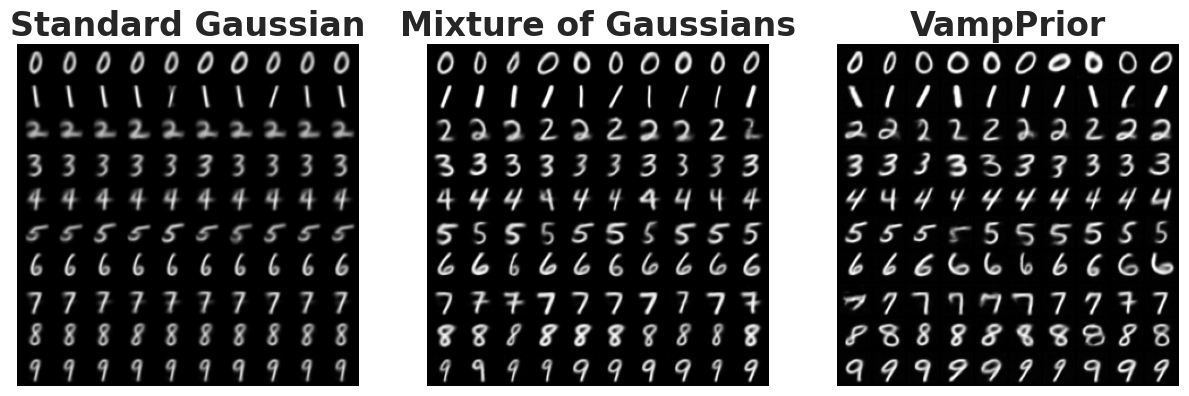

In [14]:
epochs = 100
latent_size = 2

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 10))

for i, prior_type in enumerate(["std", "mog", "vamp"]):
    img = WImage(
        filename=SAMPLE_DIR
            / f"mnist_divae_{prior_type}_{latent_size}_latentdim_{epochs}_n_epochs.png"
        )
    ax[i].imshow(img)
    ax[i].set_title(PRIOR_NAME_MAP[prior_type], weight="bold")
    ax[i].axis("off")

plt.show()

*Latent Space*

<>:71: SyntaxWarning: invalid escape sequence '\p'
<>:71: SyntaxWarning: invalid escape sequence '\p'
/home/alzub/tmp/ipykernel_1259274/837526154.py:71: SyntaxWarning: invalid escape sequence '\p'
  0.1, -0.6, f"ELBO:\n{-elbo_mean:.3f} $\pm$ {elbo_var:.3f}",
/home/alzub/tmp/ipykernel_1259274/837526154.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start se

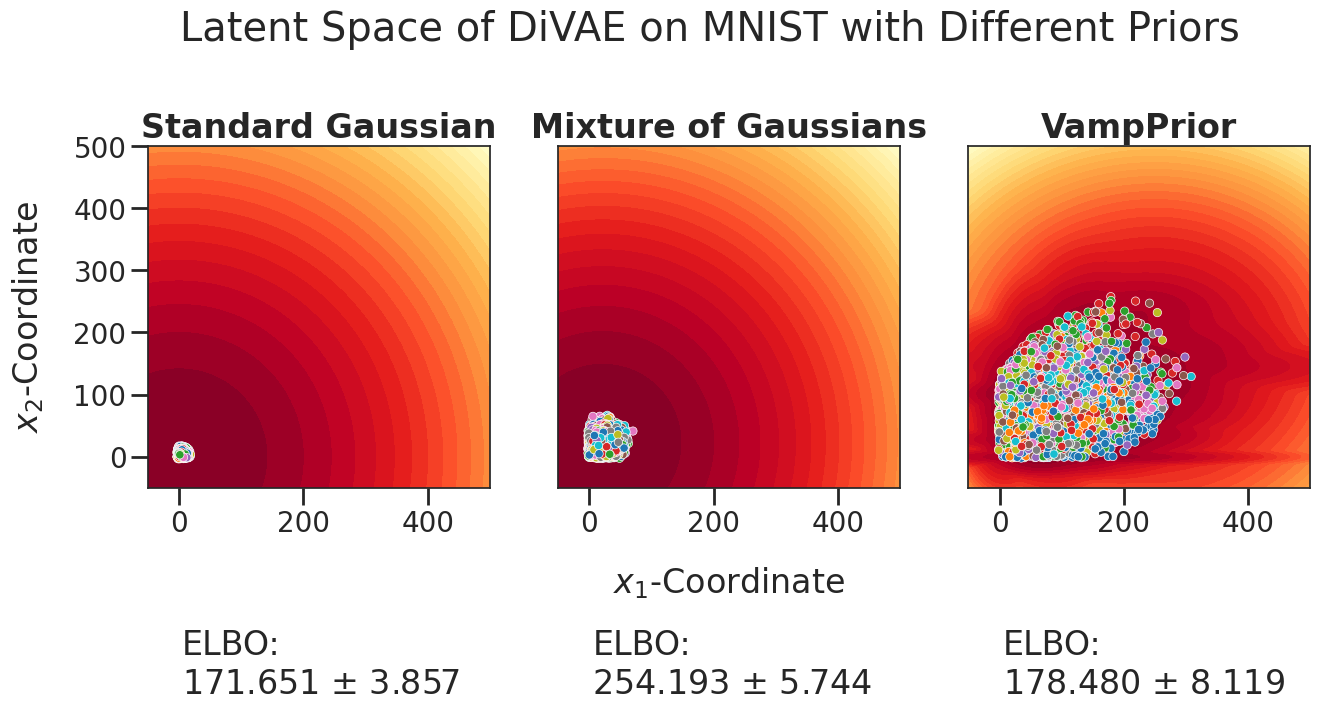

In [15]:
x_sample = next(iter(mnist_train_loader))[0][:1]
_, n_channels, height, width  = x_sample.size()
epochs = 100

latent_size = 2
embedding_size = 128
n_classes = 10

fig = plt.figure(figsize=(15, 15))
gs_plot = fig.add_gridspec(1, 3)#, bottom=0.1)
#gs_cbar = fig.add_gridspec(1, 1, top=0.27, bottom=0.26, left=0.3, right=0.7)

for i, prior_type in enumerate(["std", "mog", "vamp"]):
    enc = GaussianEncoder(make_mnist_enc_net(
        height, n_channels, embedding_size, latent_size, n_classes))
    dec = GaussianDecoder(
        make_mnist_dec_net(embedding_size, latent_size, n_classes),
        (n_channels, height, width), variance_type="scalar"
    )
    match prior_type:
        case "std":
            prior = GaussianBase((latent_size,))
        case "mog":
            prior = MixtureOfGaussiansBase(
                (latent_size,), 15, logvar_bounds=(-4.0, 3.0))
        case "vamp":
            prior = VampBase(
                (n_channels, height, width), 200, enc, n_classes=n_classes)
    model = VAE(prior, enc, dec).to(DEVICE)

    model.load_state_dict(torch.load(
        MODEL_DIR
            / f"mnist_divae_{prior_type}_{latent_size}_latentdim_{epochs}_n_epochs.pt",
        map_location=torch.device(DEVICE)
    ))

    post_df = evaluate_aggregate_posterior(model, mnist_test_loader)
    X, Y, pdf = evaluate_prior_pdf(
        (-50, -50),
        (500, 500),
        model.prior()
    )

    ax = fig.add_subplot(gs_plot[i])
    im = ax.contourf(
        X, Y, pdf, levels=30, cmap="YlOrRd",
        norm=Normalize(vmin=pdf.min(), vmax=pdf.max())
    )
    sns.scatterplot(
        data=post_df, x="x", y="y", hue="class", ax=ax, legend=False)

    ax.set_xlim(-50, 500)
    ax.set_ylim(-50, 500)
    ax.set_aspect("equal")
        
    if i > 0:
        ax.tick_params(left=False, labelleft=False)
        ax.set_ylabel("")
    else:
        ax.set_ylabel("$x_2$-Coordinate", labelpad=20)
    
    if i != 1:
        ax.set_xlabel("")
    else:
        ax.set_xlabel("$x_1$-Coordinate", labelpad=20)
    
    ax.set_title(PRIOR_NAME_MAP[prior_type], weight="bold")
    elbo_var, elbo_mean = evaluate_elbo(
        model, mnist_test_loader, reduction="mean")
    ax.text(
        0.1, -0.6, f"ELBO:\n{-elbo_mean:.3f} $\pm$ {elbo_var:.3f}",
        transform=ax.transAxes
    )

#ax_cbar = fig.add_subplot(gs_cbar[0])
#fig.colorbar(im, location="bottom", cax=ax_cbar)

fig.suptitle("Latent Space of DiVAE on MNIST with Different Priors", y=0.7)

plt.show()